<a href="https://colab.research.google.com/github/Sibitenda/Masters_MIS/blob/main/Data%20Analysis%20and%20Visualisation/week2_EDA/EDA_Practicals_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) Practicals
Notebook with two examples per topic, aligned to course slides.

## 1. Introduction to EDA


In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm

# Example 1: Titanic dataset
df1 = sns.load_dataset("titanic")
print(df1.head())

# Example 2: Diamonds dataset
df2 = sns.load_dataset("diamonds")
print(df2.head())


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.

## 2. Univariate Non-Graphical


In [ ]:

# Example 1: Titanic Age
print("Mean:", df1['age'].mean(), "Median:", df1['age'].median(),
      "Mode:", df1['age'].mode()[0], "Std:", df1['age'].std(),
      "Skew:", df1['age'].skew(), "Kurtosis:", df1['age'].kurt())

# Example 2: Diamonds Price
print("Mean:", df2['price'].mean(), "Median:", df2['price'].median(),
      "Mode:", df2['price'].mode()[0], "Std:", df2['price'].std(),
      "Skew:", df2['price'].skew(), "Kurtosis:", df2['price'].kurt())


Mean: 29.69911764705882 Median: 28.0 Mode: 24.0 Std: 14.526497332334044 Skew: 0.38910778230082704 Kurtosis: 0.17827415364210353
Mean: 3932.799721913237 Median: 2401.0 Mode: 605 Std: 3989.4397381463023 Skew: 1.618395283383529 Kurtosis: 2.17769575924869


## 3. Multivariate Non-Graphical


In [ ]:

# Example 1: Titanic
print(pd.crosstab(df1['sex'], df1['class'], margins=True))

# Example 2: Diamonds
print(pd.crosstab(df2['cut'], df2['color'], margins=True))


class   First  Second  Third  All
sex                              
female     94      76    144  314
male      122     108    347  577
All       216     184    491  891
color         D     E     F      G     H     I     J    All
cut                                                        
Ideal      2834  3903  3826   4884  3115  2093   896  21551
Premium    1603  2337  2331   2924  2360  1428   808  13791
Very Good  1513  2400  2164   2299  1824  1204   678  12082
Good        662   933   909    871   702   522   307   4906
Fair        163   224   312    314   303   175   119   1610
All        6775  9797  9542  11292  8304  5422  2808  53940


## 4. Univariate Graphical


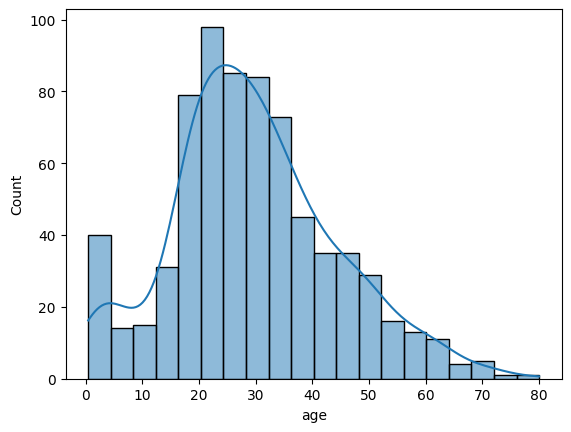

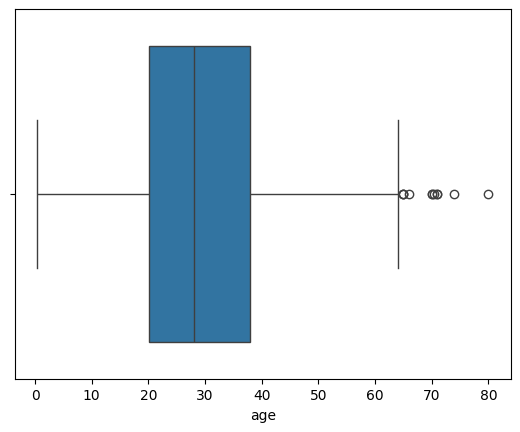

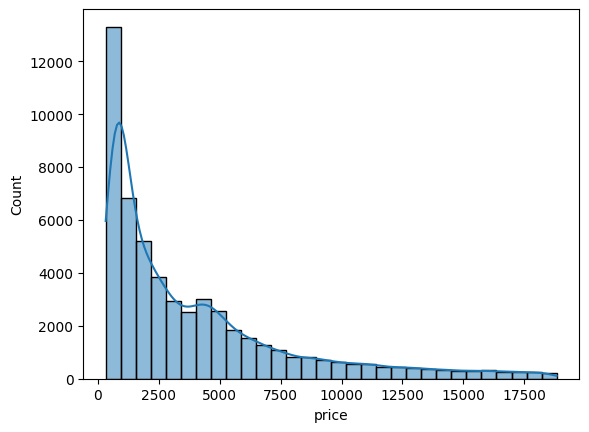

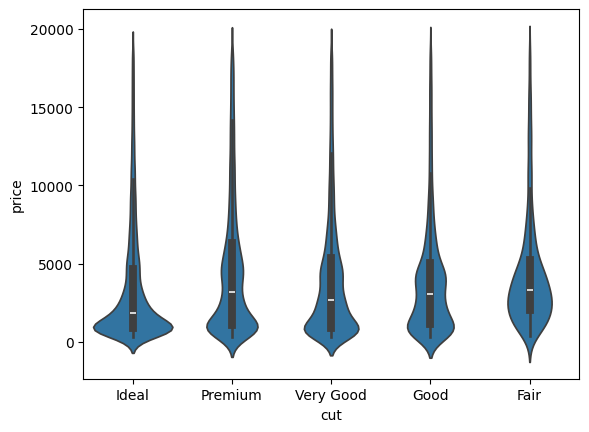

In [ ]:

# Example 1: Titanic Age
sns.histplot(df1['age'].dropna(), kde=True); plt.show()
sns.boxplot(x=df1['age']); plt.show()

# Example 2: Diamonds Price
sns.histplot(df2['price'], kde=True, bins=30); plt.show()
sns.violinplot(x=df2['cut'], y=df2['price']); plt.show()


## 5. Multivariate Graphical


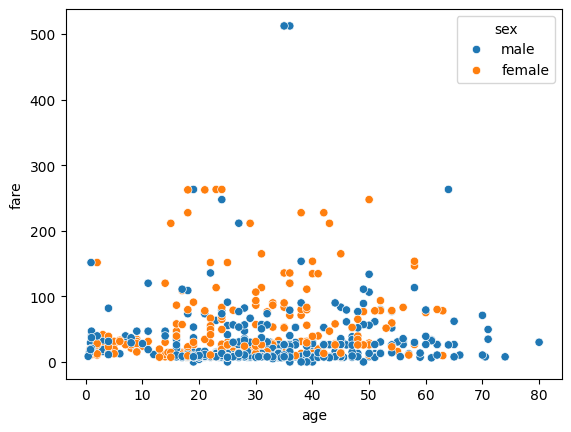

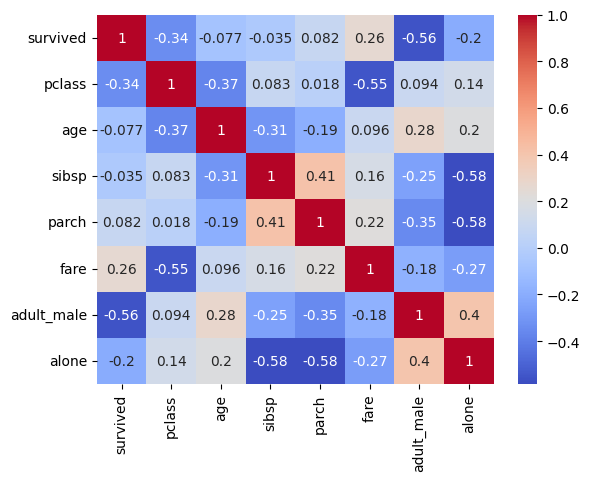

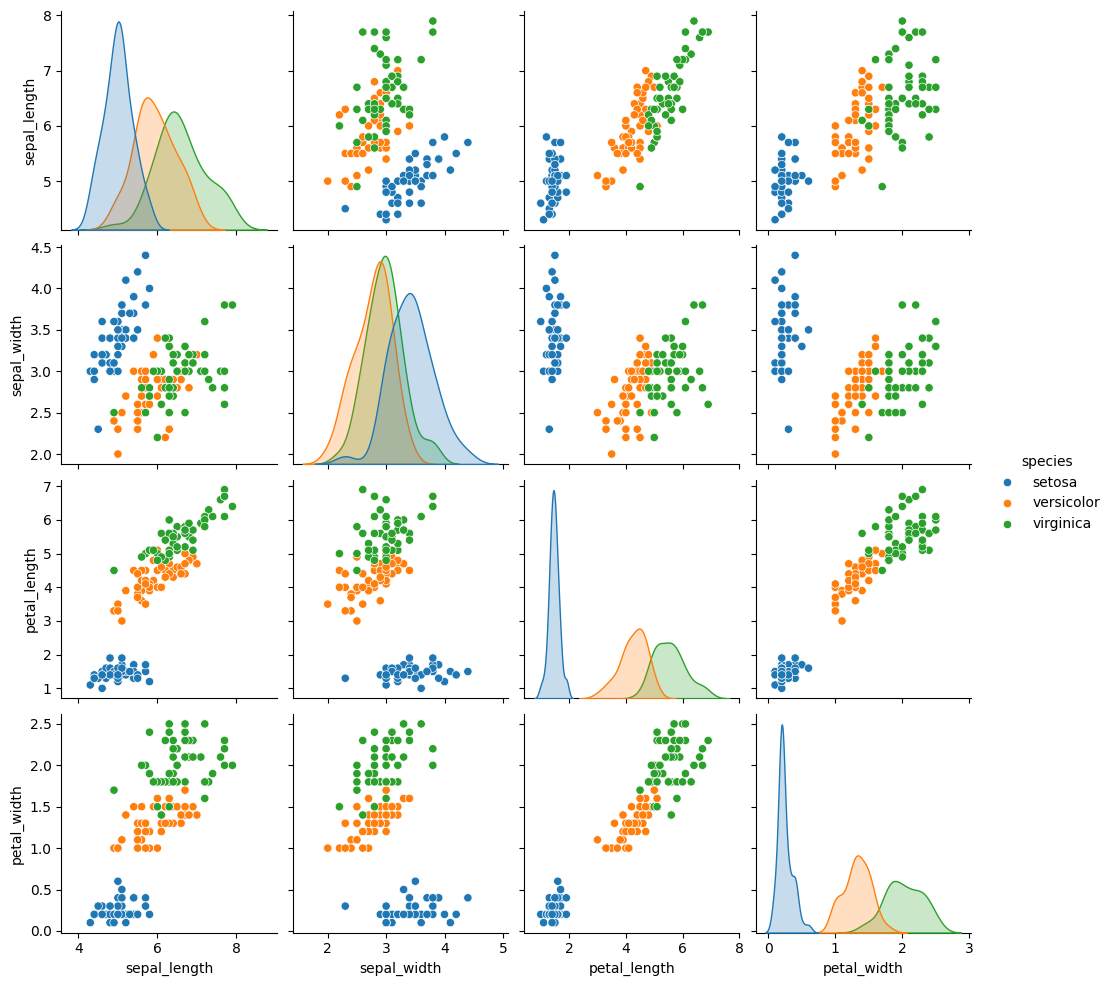

In [ ]:

# Example 1: Titanic
sns.scatterplot(x='age', y='fare', hue='sex', data=df1); plt.show()
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap="coolwarm"); plt.show()

# Example 2: Iris
iris = sns.load_dataset("iris")
sns.pairplot(iris, hue="species"); plt.show()


## 6. Descriptive Statistics


In [ ]:

# Example 1: Titanic Fare
print(df1['fare'].quantile([0.25, 0.5, 0.75]))

# Example 2: Diamonds Carat
print(df2['carat'].quantile([0.25, 0.5, 0.75]))


0.25     7.9104
0.50    14.4542
0.75    31.0000
Name: fare, dtype: float64
0.25    0.40
0.50    0.70
0.75    1.04
Name: carat, dtype: float64


## 7. Normality & Distribution


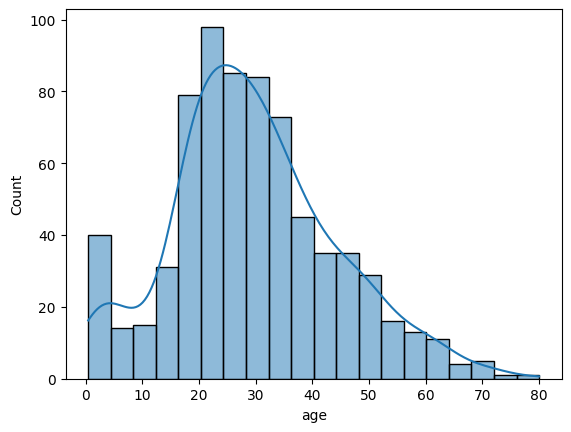

ShapiroResult(statistic=np.float64(0.9814577414504954), pvalue=np.float64(7.337348958673594e-08))


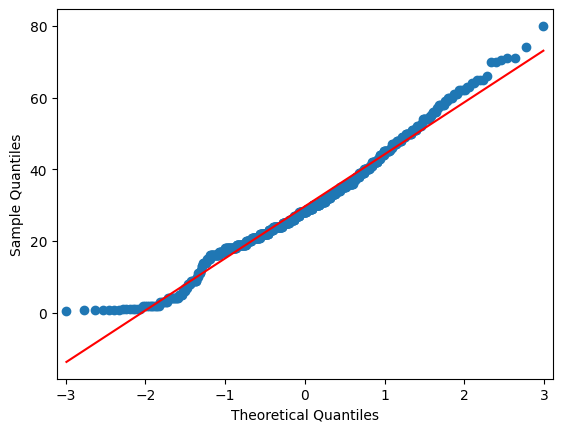

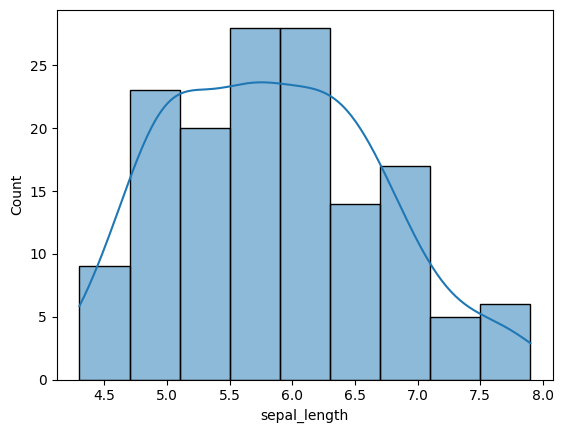

ShapiroResult(statistic=np.float64(0.9760902723490532), pvalue=np.float64(0.010181161454691156))


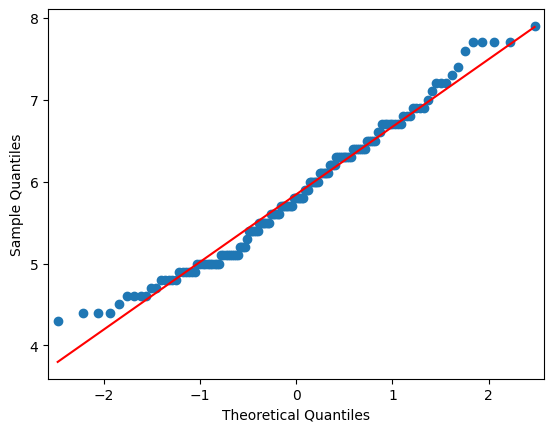

In [ ]:

# Example 1: Titanic Age
sns.histplot(df1['age'].dropna(), kde=True); plt.show()
print(stats.shapiro(df1['age'].dropna()))
sm.qqplot(df1['age'].dropna(), line='s'); plt.show()

# Example 2: Iris Sepal Length
sns.histplot(iris['sepal_length'], kde=True); plt.show()
print(stats.shapiro(iris['sepal_length']))
sm.qqplot(iris['sepal_length'], line='s'); plt.show()


## 8. Transformation


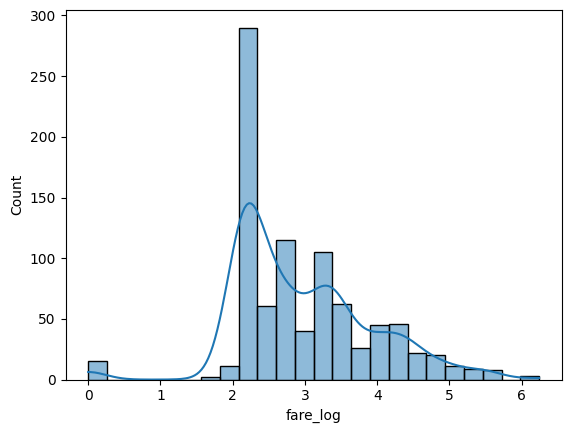

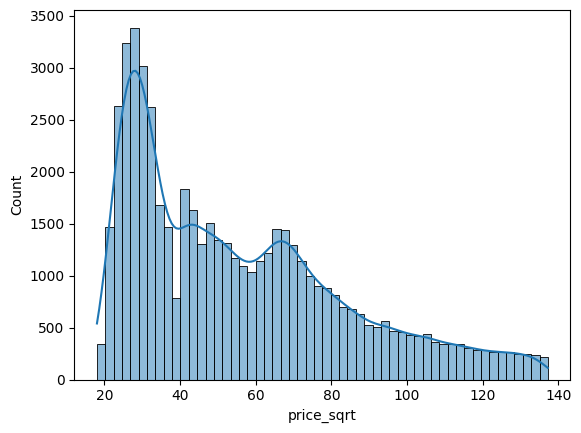

In [ ]:

# Example 1: Titanic Fare log
df1['fare_log'] = np.log1p(df1['fare'])
sns.histplot(df1['fare_log'], kde=True); plt.show()

# Example 2: Diamonds Price sqrt
df2['price_sqrt'] = np.sqrt(df2['price'])
sns.histplot(df2['price_sqrt'], kde=True); plt.show()


## 9. Prevalence & Incidence


In [ ]:

# Example 1: Prevalence
pop = 598; cases = 65
print("Prevalence:", cases/pop*100, "%")

# Example 2: Incidence
new_cases = 176; healthy = 9888
print("Incidence:", new_cases/healthy*100, "%")


Prevalence: 10.869565217391305 %
Incidence: 1.779935275080906 %


## 10. Categorical Visualization


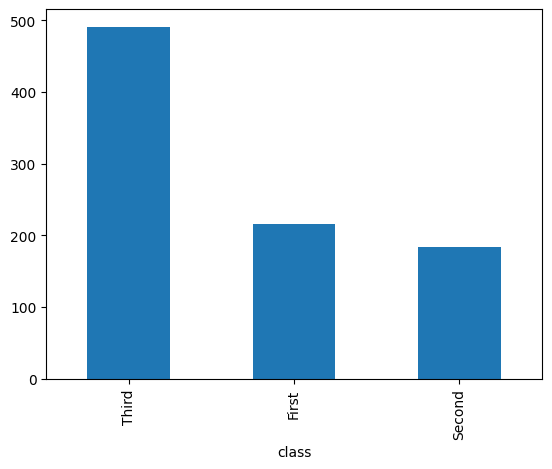

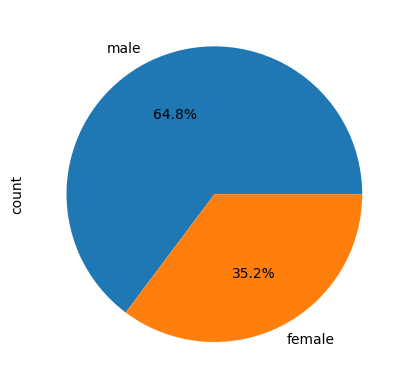

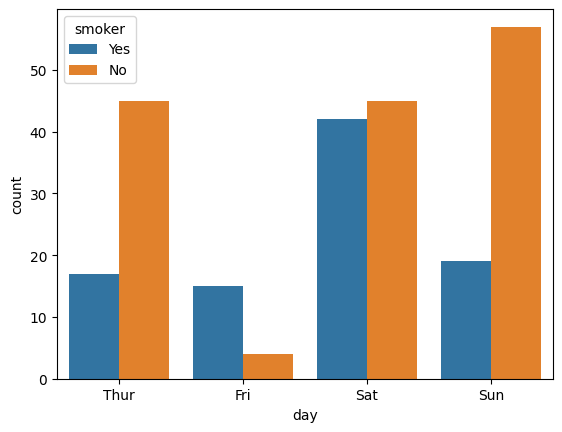

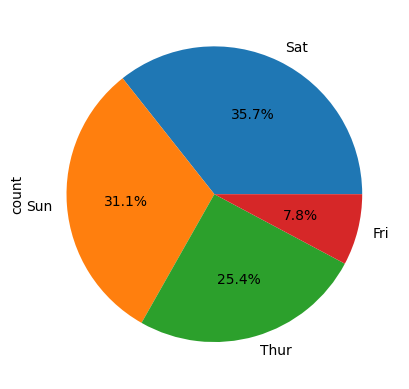

In [ ]:

# Example 1: Titanic
df1['class'].value_counts().plot(kind='bar'); plt.show()
df1['sex'].value_counts().plot(kind='pie', autopct='%1.1f%%'); plt.show()

# Example 2: Tips
tips = sns.load_dataset("tips")
sns.countplot(x="day", hue="smoker", data=tips); plt.show()
tips['day'].value_counts().plot(kind='pie', autopct='%1.1f%%'); plt.show()


## 11. Bivariate Numerical


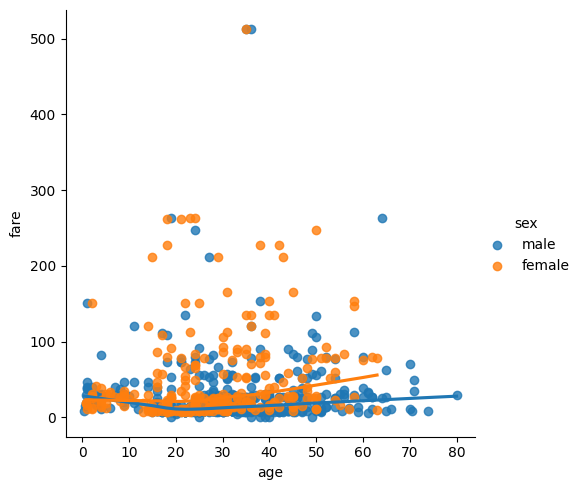

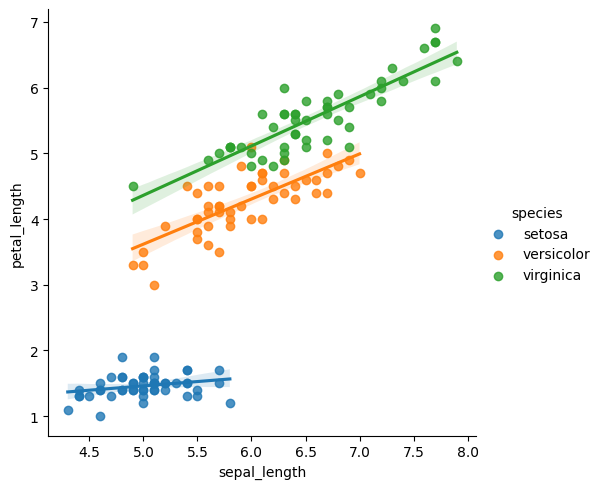

In [ ]:

# Example 1: Titanic
sns.lmplot(x='age', y='fare', hue='sex', data=df1, lowess=True); plt.show()

# Example 2: Iris
sns.lmplot(x='sepal_length', y='petal_length', hue='species', data=iris); plt.show()


## 12. Wrap-up


In [ ]:

# Try with your own dataset
# df_custom = pd.read_csv("your_data.csv")
# df_custom.describe()
print("Now try applying EDA methods on your own dataset!")


Now try applying EDA methods on your own dataset!
